<a href="https://colab.research.google.com/github/erenozelll/2026Spring-04-Earthquake_Prediction/blob/main/group_collab_earthquake_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Kütüphaneler
#EREN
import pandas as pd
import numpy as np
import os

# Klasörlerin var olduğundan emin olalım (Colab geçici ortam olduğu için)
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print("Kütüphaneler yüklendi ve klasörler hazır.")

Kütüphaneler yüklendi ve klasörler hazır.


In [4]:
#EREN
file_path = '/content/data/raw/koeri_raw_v2.txt'

# sep='\t' parametresi ile Pandas'a bu dosyadaki sütunlar TAB ile ayrılmıştır diyoruz.
try:
    df = pd.read_csv(file_path, sep='\t', encoding='windows-1254')
except Exception:
    df = pd.read_csv(file_path, sep='\t', encoding='iso-8859-9')

# Sütun isimlerinin başında/sonunda yanlışlıkla kalmış boşluklar varsa temizleyelim
df.columns = df.columns.str.strip()

# Proje için sadece ihtiyacımız olan sütunları seçelim ve isimlerini düzeltelim
df = df[['Olus tarihi', 'Olus zamani', 'Enlem', 'Boylam', 'Der(km)', 'MD', 'ML', 'Mw', 'Yer']]

df.columns = ['Olus_tarihi', 'Olus_zamani', 'Enlem', 'Boylam', 'Der_km', 'MD', 'ML', 'Mw', 'Yer']

print("Sekme (TAB) ayracı ile veri mükemmel şekilde okundu!")
display(df.head())
display(df.tail())

Sekme (TAB) ayracı ile veri mükemmel şekilde okundu!


,Olus_tarihi,Olus_zamani,Enlem,Boylam,Der_km,MD,ML,Mw,Yer
0,2024.12.31,10:46:27.00,38.0710,37.5068,6.7,0.0,4.0,3.9,TATLAR-NURHAK (KAHRAMANMARAS) [North West 8.1...
1,2024.12.30,20:30:27.56,39.4170,37.2977,5.0,0.0,4.3,4.3,KERTMEKARACAOREN-ULAS (SIVAS) [South West 2.1...
2,2024.12.30,02:25:17.55,36.7442,30.1467,7.1,0.0,3.9,3.8,OVACIK-ELMALI (ANTALYA) [South West 6.4 km]
3,2024.12.29,00:15:10.00,35.1408,27.2722,10.6,0.0,4.1,4.3,AKDENIZ
4,2024.12.28,11:44:00.95,41.2442,44.0308,5.0,0.0,3.6,3.7,GURCISTAN


,Olus_tarihi,Olus_zamani,Enlem,Boylam,Der_km,MD,ML,Mw,Yer
22787,1901.04.01,00:00:01.00,38.4,31.4,5.0,5.0,0.0,NaN,ATAKENT-AKSEHIR (KONYA) [North East 2.4 km]
22788,1901.03.01,00:00:01.00,38.2,27.7,5.0,5.0,0.0,NaN,YAKACIK-BAYINDIR (IZMIR) [South West 0.8 km]
22789,1901.02.23,00:00:00.00,37.9,27.9,15.0,4.7,4.6,4.8,KENGER- (AYDIN) [North East 1.1 km]
22790,1900.09.20,00:00:01.00,37.8,29.1,5.0,5.0,0.0,NaN,DENIZLI (DENIZLI) [North East 2.3 km]
22791,1900.04.17,02:23:00.00,42.2,45.1,35.0,4.7,4.6,4.8,GÜRCISTAN


In [5]:
#EREN
# 1. Tarih ve Saati birleştirip gerçek datetime tipine çevirme
df['datetime'] = pd.to_datetime(df['Olus_tarihi'] + ' ' + df['Olus_zamani'], errors='coerce')

# 2. Sayısal olması gereken sütunları float'a  çevirme
numeric_cols = ['Enlem', 'Boylam', 'Der_km', 'MD', 'ML', 'Mw']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Büyüklük Önceliği Kuralı (Mw > ML > MD)
conditions = [
    df['Mw'].notna() & (df['Mw'] > 0),
    df['ML'].notna() & (df['ML'] > 0),
    df['MD'].notna() & (df['MD'] > 0)
]
choices = [df['Mw'], df['ML'], df['MD']]
df['magnitude'] = np.select(conditions, choices, default=np.nan)

# 4. Proje standartlarına (İngilizce isimlere) çevir
df = df.rename(columns={
    'Enlem': 'lat',
    'Boylam': 'lon',
    'Der_km': 'depth_km'
})

print("Tip dönüşümleri ve magnitüd hiyerarşisi tamamlandı.")
display(df[['datetime', 'lat', 'lon', 'depth_km', 'magnitude']].head())

Tip dönüşümleri ve magnitüd hiyerarşisi tamamlandı.


,datetime,lat,lon,depth_km,magnitude
0,2024-12-31 10:46:27.000,38.0710,37.5068,6.7,3.9
1,2024-12-30 20:30:27.560,39.4170,37.2977,5.0,4.3
2,2024-12-30 02:25:17.550,36.7442,30.1467,7.1,3.8
3,2024-12-29 00:15:10.000,35.1408,27.2722,10.6,4.3
4,2024-12-28 11:44:00.950,41.2442,44.0308,5.0,3.7


In [6]:
#EREN
# Orijinal boyutu not alalım
baslangic_boyutu = len(df)

# Sadece makine öğrenmesi modelinde kullanacağımız sütunları seçelim
df_clean = df[['datetime', 'lat', 'lon', 'depth_km', 'magnitude']].copy()

# Eksik (NaN) veya hatalı değerleri sil
df_clean = df_clean.dropna()

# Mantıksız verileri temizle (Örn: negatif derinlik veya aşırı büyük magnitüd)
df_clean = df_clean[
    (df_clean['magnitude'] > 0) & (df_clean['magnitude'] <= 9.0) &
    (df_clean['depth_km'] >= 0) & (df_clean['depth_km'] <= 700)
]

# Proje Kutu Filtresi
df_clean = df_clean[
    (df_clean['lat'] >= 35.0) & (df_clean['lat'] <= 43.0) &
    (df_clean['lon'] >= 25.0) & (df_clean['lon'] <= 46.0)
]

# Aynı saniye ve koordinattaki duplicate kayıtları sil
df_clean = df_clean.drop_duplicates(subset=['datetime', 'lat', 'lon'])

# Kronolojik sırala
df_clean = df_clean.sort_values('datetime').reset_index(drop=True)

bitis_boyutu = len(df_clean)

print("--- VERİ TEMİZLİĞİ ÖZETİ ---")
print(f"Başlangıçtaki Satır Sayısı: {baslangic_boyutu}")
print(f"Kutu Dışı ve Hatalı Silinen: {baslangic_boyutu - bitis_boyutu}")
print(f"Eğitime Hazır Temiz Veri: {bitis_boyutu}")


# CSV formatında kaydet
output_path = 'data/processed/koeri_clean.csv'

# index=False ile satır numaralarını kaydetmiyoruz
df_clean.to_csv(output_path, index=False)

print(f"\n Aşama 1 Başarılı! Temiz veri '{output_path}' konumuna kaydedildi.")

--- VERİ TEMİZLİĞİ ÖZETİ ---
Başlangıçtaki Satır Sayısı: 22792
Kutu Dışı ve Hatalı Silinen: 2394
Eğitime Hazır Temiz Veri: 20398

 Aşama 1 Başarılı! Temiz veri 'data/processed/koeri_clean.csv' konumuna kaydedildi.


In [7]:
# ALP & TAHA
import pandas as pd
import numpy as np

# Temizlenmiş CSV dosyamızı yüklüyoruz
df = pd.read_csv('data/processed/koeri_clean.csv')

# CSV'den okuduğumuz datetime sütununu tekrar tarih formatına çevirmemiz lazım
df['datetime'] = pd.to_datetime(df['datetime'])

# Zamana göre sıralı mı
df = df.sort_values('datetime').reset_index(drop=True)

# ---------------------------------------------------------
# 1. HEDEF DEĞİŞKEN - Taha
# ---------------------------------------------------------
df['target'] = (df['magnitude'] >= 4.0).astype(int)

oran = df['target'].mean() * 100
print(f"Hedef Değişken (Target) Oluşturuldu.")
print(f"Toplam Deprem: {len(df)}")
print(f"4.0 Üzeri Deprem Sayısı (Pozitif Sınıf): {df['target'].sum()}")
print(f"Pozitif Sınıf Oranı: %{oran:.2f}\n")

# ---------------------------------------------------------
# 2. LAG ÖZELLİKLERİ (Geçmiş Zaman) - Alp
# ---------------------------------------------------------
df['time_since_last_event_hours'] = df['datetime'].diff().dt.total_seconds() / 3600.0
df['prev_magnitude'] = df['magnitude'].shift(1)

print("Geçmiş (Lag) özellikleri eklendi.")
display(df[['datetime', 'magnitude', 'target', 'time_since_last_event_hours', 'prev_magnitude']].head())
display(df[['datetime', 'magnitude', 'target', 'time_since_last_event_hours', 'prev_magnitude']].tail())

Hedef Değişken (Target) Oluşturuldu.
Toplam Deprem: 20398
4.0 Üzeri Deprem Sayısı (Pozitif Sınıf): 7341
Pozitif Sınıf Oranı: %35.99

Geçmiş (Lag) özellikleri eklendi.


,datetime,magnitude,target,time_since_last_event_hours,prev_magnitude
0,1900-04-17 02:23:00,4.8,1,NaN,NaN
1,1900-09-20 00:00:01,5.0,1,3741.616944,4.8
2,1901-02-23 00:00:00,4.8,1,3743.999722,5.0
3,1901-03-01 00:00:01,5.0,1,144.000278,4.8
4,1901-04-01 00:00:01,5.0,1,744.000000,5.0


,datetime,magnitude,target,time_since_last_event_hours,prev_magnitude
20393,2024-12-28 11:44:00.950,3.7,0,40.923881,3.5
20394,2024-12-29 00:15:10.000,4.3,1,12.519181,3.7
20395,2024-12-30 02:25:17.550,3.8,0,26.168764,4.3
20396,2024-12-30 20:30:27.560,4.3,1,18.086114,3.8
20397,2024-12-31 10:46:27.000,3.9,0,14.266511,4.3


In [8]:
#ALP
# 3. ROLLING ÖZELLİKLERİ

import pandas as pd
import numpy as np

# Pandas rolling index üzerinden çalıştığı için datetime'ı index yapıyoruz
df_roll = df.set_index('datetime').copy()

# Pencerelerimiz: 7 gün ve 30 gün
windows = ['7D', '30D']

for w in windows:
    # 1. Belirli bir penceredeki toplam deprem sayısı
    # closed='left' Şu an olan depremi sayma, sadece öncekileri say
    count_col = f'count_events_{w}'
    df_roll[count_col] = df_roll['magnitude'].rolling(window=w, closed='left').count()

    # 2. Belirli bir penceredeki maksimum magnitüd
    max_col = f'max_mag_{w}'
    df_roll[max_col] = df_roll['magnitude'].rolling(window=w, closed='left').max()

    # 3. Belirli bir penceredeki ortalama büyüklük
    mean_col = f'mean_mag_{w}'
    df_roll[mean_col] = df_roll['magnitude'].rolling(window=w, closed='left').mean()

# Index'i geri sütuna alıyoruz
df = df_roll.reset_index()

# Rolling hesaplamaları başlardaki satırlar için (geçmişi olmadığı için) boş (NaN) değerler üretecektir.
print(f"Rolling öncesi satır sayısı: {len(df)}")
df_features = df.dropna().reset_index(drop=True)
print(f"Eksik (NaN) özellikler silindikten sonra satır sayısı: {len(df_features)}")

print("\nKayan Pencere (Rolling) özellikleri eklendi ve Leakage (Sızıntı) engellendi!")
display(df_features[['datetime', 'magnitude', 'count_events_7D', 'max_mag_30D']].tail())

Rolling öncesi satır sayısı: 20398
Eksik (NaN) özellikler silindikten sonra satır sayısı: 19297

Kayan Pencere (Rolling) özellikleri eklendi ve Leakage (Sızıntı) engellendi!


,datetime,magnitude,count_events_7D,max_mag_30D
19292,2024-12-28 11:44:00.950,3.7,6.0,4.7
19293,2024-12-29 00:15:10.000,4.3,7.0,4.7
19294,2024-12-30 02:25:17.550,3.8,7.0,4.7
19295,2024-12-30 20:30:27.560,4.3,8.0,4.7
19296,2024-12-31 10:46:27.000,3.9,9.0,4.7


In [9]:
#EFE
import pandas as pd

# 1. Final Özellik Matrisini Kaydetme
output_features = 'data/processed/features.csv'
df_features.to_csv(output_features, index=False)
print(f"Final özellik matrisi kaydedildi: {output_features}")

# 2. MODEL İÇİN GEREKSİZ SÜTUNLARI ÇIKARMA
# datetime sadece bölme işlemi için kullanılacak, modele girmeyecek.
# magnitude zaten target'ın kendisi (4.0 üstü mü değil mi), o yüzden modele veremeyiz (büyük bir leakage olur)
drop_cols = ['datetime', 'magnitude', 'target']
X = df_features.drop(columns=drop_cols)
y = df_features['target']
tarihler = df_features['datetime']

# 3. KRONOLOJİK BÖLÜNME
# Train: 1900 - 2019 sonu
# Val: 2020 - 2022 sonu
# Test: 2023 - 2024 sonu

train_mask = (tarihler >= '1900-01-01') & (tarihler <= '2019-12-31')
val_mask = (tarihler >= '2020-01-01') & (tarihler <= '2022-12-31')
test_mask = (tarihler >= '2023-01-01') & (tarihler <= '2024-12-31')

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("\n--- Veri Seti Bölünme Özeti ---")
print(f"Eğitim (Train) Seti: {len(X_train)} satır")
print(f"Doğrulama (Val) Seti: {len(X_val)} satır")
print(f"Test Seti: {len(X_test)} satır (Sona kadar dokunulmayacak!)")

Final özellik matrisi kaydedildi: data/processed/features.csv

--- Veri Seti Bölünme Özeti ---
Eğitim (Train) Seti: 15016 satır
Doğrulama (Val) Seti: 1920 satır
Test Seti: 2360 satır (Sona kadar dokunulmayacak!)


Logistic Regression Baseline modeli eğitiliyor...
Eğitim tamamlandı!

--- BASELINE (LOGISTIC REGRESSION) VALIDATION SONUÇLARI ---
PR-AUC (Birincil Metrik) : 0.3743
ROC-AUC                  : 0.5596
Recall (Duyarlılık)      : 0.2797
F1 Skoru                 : 0.3231



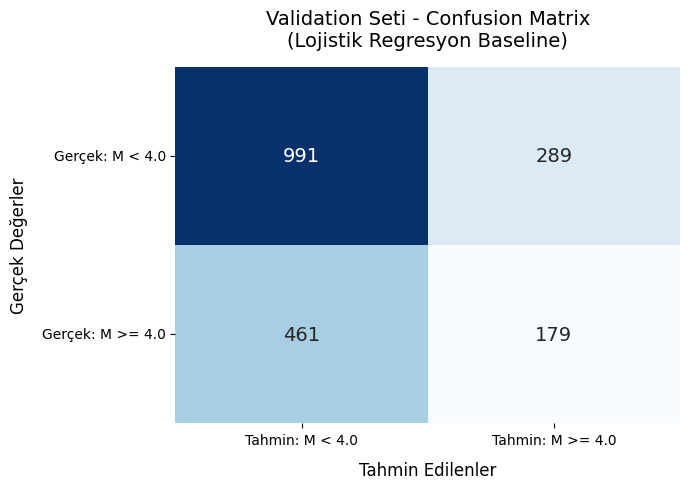

In [10]:
#ESMA & TAHA & EFE
import warnings
warnings.filterwarnings('ignore') # Matplotlib veya Sklearn'den gelebilecek gereksiz uyarıları gizler

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. PIPELINE KURULUMU -Esma
# ---------------------------------------------------------
# Standartlaştırma (Scaler) ve Modeli birleştiriyoruz.
# class_weight='balanced' dengesiz sınıf dağılımını modelin gözünde eşitler.
# max_iter=1000 iterasyon limitini yüksek tutarak modelin yakınsamasını garantiliyoruz.
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Modeli SADECE Eğitim setiyle (1900-2019 arası verilerle) eğitiyoruz
print("Logistic Regression Baseline modeli eğitiliyor...")
pipeline_lr.fit(X_train, y_train)
print("Eğitim tamamlandı!\n")

# ---------------------------------------------------------
# 2. VALIDATION SETİ ÜZERİNDE TAHMİN
# ---------------------------------------------------------
# Modeli, daha önce hiç görmediği 2020-2022 yılları üzerinde test ediyoruz
y_val_pred = pipeline_lr.predict(X_val)
y_val_proba = pipeline_lr.predict_proba(X_val)[:, 1] # PR-AUC ve ROC-AUC için 1 (Pozitif) sınıfının olasılıkları

# ---------------------------------------------------------
# 3. METRİKLER -Taha
# ---------------------------------------------------------
# Proje planındaki birincil metrik PR-AUC'dur (Dengesiz veri setleri için en sağlıklısı).
pr_auc = average_precision_score(y_val, y_val_proba)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

print("--- BASELINE (LOGISTIC REGRESSION) VALIDATION SONUÇLARI ---")
print(f"PR-AUC (Birincil Metrik) : {pr_auc:.4f}")
print(f"ROC-AUC                  : {roc_auc:.4f}")
print(f"Recall (Duyarlılık)      : {recall:.4f}")
print(f"F1 Skoru                 : {f1:.4f}\n")

# ---------------------------------------------------------
# Confusion Matrix - Efe
# ---------------------------------------------------------
cm = confusion_matrix(y_val, y_val_pred)

# Görselleştirmeyi biraz daha modern ve okunabilir hale getirdik
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin: M < 4.0', 'Tahmin: M >= 4.0'],
            yticklabels=['Gerçek: M < 4.0', 'Gerçek: M >= 4.0'],
            cbar=False, annot_kws={"size": 14}) # Rakamları büyüttük, gereksiz renk skalasını kaldırdık

plt.title('Validation Seti - Confusion Matrix\n(Lojistik Regresyon Baseline)', fontsize=14, pad=15)
plt.ylabel('Gerçek Değerler', fontsize=12, labelpad=10)
plt.xlabel('Tahmin Edilenler', fontsize=12, labelpad=10)
plt.yticks(rotation=0) # Y ekseni yazılarının dik durmasını sağladık
plt.tight_layout()
plt.show()

XGBoost için scale_pos_weight değeri: 2.04
XGBoost modeli eğitiliyor...
Eğitim tamamlandı! (Optimum Ağaç Sayısı: 104)

--- XGBOOST VALIDATION SONUÇLARI ---
PR-AUC (Birincil Metrik) : 0.3641 (Baseline LR: 0.2339)
ROC-AUC                  : 0.5344
Recall (Duyarlılık)      : 0.1500
F1 Skoru                 : 0.2187



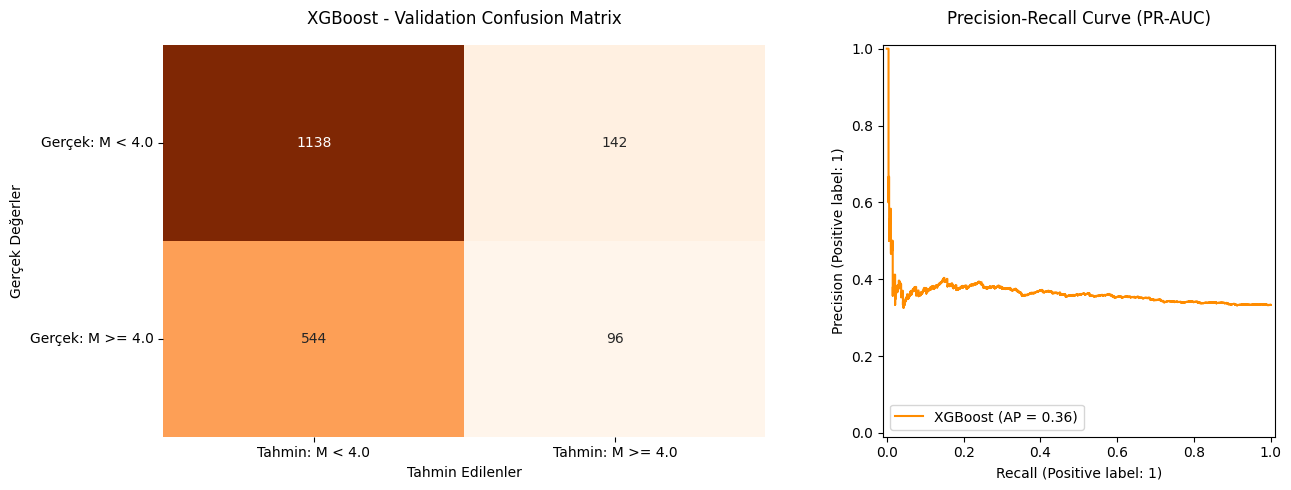

In [11]:
#EFE & TAHA
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.metrics import average_precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, PrecisionRecallDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. Sınıf Dengesizliği İçin Ölçekleme (scale_pos_weight)
# ---------------------------------------------------------
# Negatif Sınıf (0) Sayısı / Pozitif Sınıf (1) Sayısı
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_weight = neg_class_count / pos_class_count

print(f"XGBoost için scale_pos_weight değeri: {scale_weight:.2f}")

# ---------------------------------------------------------
# 2. XGBoost Modelini Tanımlama
# ---------------------------------------------------------
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    random_state=42,
    early_stopping_rounds=50, #  Model 50 ağaç boyunca gelişmezse eğitimi durdurur
    n_jobs=-1
)

print("XGBoost modeli eğitiliyor...")
#  Modelin validation seti üzerinde kendini test ederek ezberlemeyi önlemesi sağlandı.
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False # Çıktı kirliliğini önlemek için eğitim loglarını gizliyoruz
)
print(f"Eğitim tamamlandı! (Optimum Ağaç Sayısı: {xgb_model.best_iteration})")

# ---------------------------------------------------------
# 3. VALIDATION SETİ ÜZERİNDE TAHMİN
# ---------------------------------------------------------
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

# ---------------------------------------------------------
# 4. METRİKLERİ HESAPLAMA
# ---------------------------------------------------------
pr_auc_xgb = average_precision_score(y_val, y_val_proba_xgb)
recall_xgb = recall_score(y_val, y_val_pred_xgb)
f1_xgb = f1_score(y_val, y_val_pred_xgb)
roc_auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)

print("\n--- XGBOOST VALIDATION SONUÇLARI ---")
# Baseline skoru Lojistik Regresyon sonucunuza göre
print(f"PR-AUC (Birincil Metrik) : {pr_auc_xgb:.4f} (Baseline LR: 0.2339)")
print(f"ROC-AUC                  : {roc_auc_xgb:.4f}")
print(f"Recall (Duyarlılık)      : {recall_xgb:.4f}")
print(f"F1 Skoru                 : {f1_xgb:.4f}\n")

# ---------------------------------------------------------
# 5. GÖRSELLEŞTİRME (Karmaşıklık Matrisi ve PR Eğrisi)
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matris
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Tahmin: M < 4.0', 'Tahmin: M >= 4.0'],
            yticklabels=['Gerçek: M < 4.0', 'Gerçek: M >= 4.0'], ax=ax[0])
ax[0].set_title('XGBoost - Validation Confusion Matrix', pad=15)
ax[0].set_ylabel('Gerçek Değerler')
ax[0].set_xlabel('Tahmin Edilenler')
ax[0].tick_params(axis='y', rotation=0)

# PR Curve (Hassasiyet-Duyarlılık Eğrisi)
PrecisionRecallDisplay.from_estimator(xgb_model, X_val, y_val, ax=ax[1], color='darkorange', name='XGBoost')
ax[1].set_title('Precision-Recall Curve (PR-AUC)', pad=15)

plt.tight_layout()
plt.show()

--- EŞİK (THRESHOLD) OPTİMİZASYONU ---
Varsayılan Eşik (0.500) -> F1 Skoru: 0.2187
Bulunan EN İYİ Eşik: 0.2476 -> Yeni F1 Skoru: 0.5002

--- YENİ EŞİK DEĞERİYLE METRİKLER ---
Yeni Recall (Duyarlılık): 0.9875 (Eski Hali: 0.1500)

--- ÖZELLİK ÖNEM SIRALAMASI (FEATURE IMPORTANCE) ---
mean_mag_30D: 0.4779
depth_km: 0.1173
lon: 0.0562
count_events_30D: 0.0555
lat: 0.0550
mean_mag_7D: 0.0450
max_mag_7D: 0.0426
max_mag_30D: 0.0423
count_events_7D: 0.0395
time_since_last_event_hours: 0.0383
prev_magnitude: 0.0304


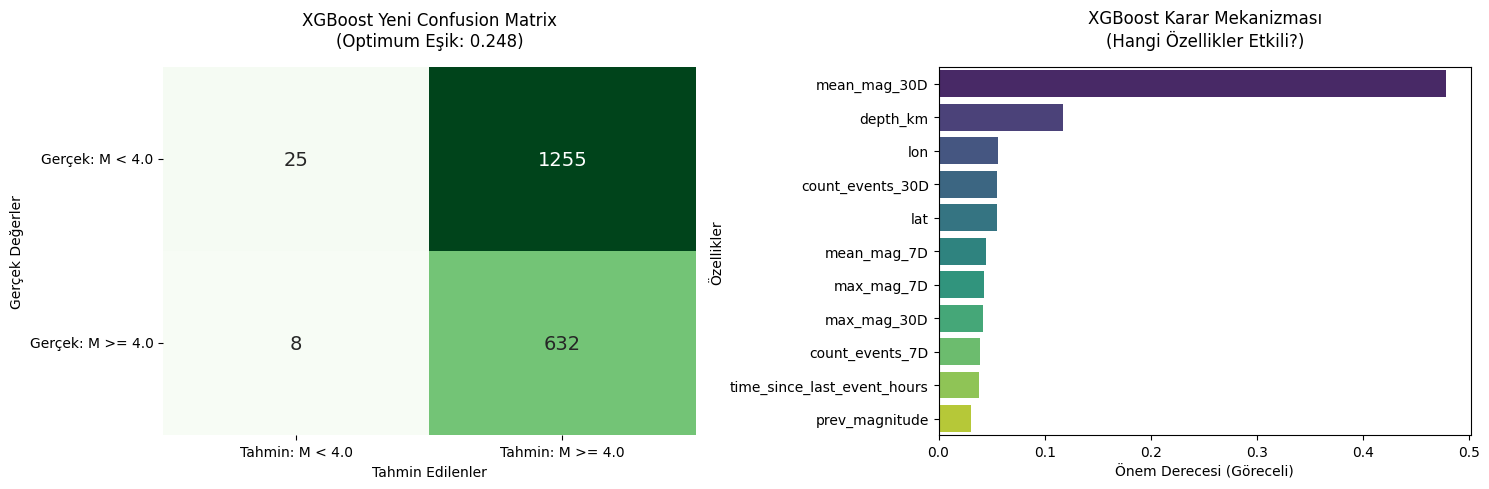

In [12]:
#ESMA & TAHA
import numpy as np
from sklearn.metrics import precision_recall_curve, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ---------------------------------------------------------
# 1. EN İYİ EŞİK DEĞERİNİ (THRESHOLD) BULMA -Taha
# ---------------------------------------------------------
# Modelin ürettiği olasılıkları alıyoruz
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_xgb)

# thresholds dizisi, precisions ve recalls dizilerinden 1 eleman kısadır
# Boyut uyumsuzluğunu (IndexError) önlemek için son elemanları dışarıda bırakarak F1 hesaplıyoruz.
f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("--- EŞİK (THRESHOLD) OPTİMİZASYONU ---")
print(f"Varsayılan Eşik (0.500) -> F1 Skoru: {f1_xgb:.4f}")
print(f"Bulunan EN İYİ Eşik: {best_threshold:.4f} -> Yeni F1 Skoru: {best_f1:.4f}\n")

# ---------------------------------------------------------
# 2. YENİ EŞİKLE MODELİ TEKRAR TEST ETME
# ---------------------------------------------------------
# Artık model 0.50 yerine bulduğumuz yeni değere göre karar verecek
y_val_pred_adjusted = (y_val_proba_xgb >= best_threshold).astype(int)
yeni_recall = recall_score(y_val, y_val_pred_adjusted)

print("--- YENİ EŞİK DEĞERİYLE METRİKLER ---")
print(f"Yeni Recall (Duyarlılık): {yeni_recall:.4f} (Eski Hali: {recall_xgb:.4f})\n")

# ---------------------------------------------------------
# 3. XGBOOST HANGİ ÖZELLİKLERE BAKIYOR? -Esma
# ---------------------------------------------------------
feature_names = X_train.columns
importances = xgb_model.feature_importances_

# Görselleştirme ve sıralama için DataFrame oluşturalım
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

print("--- ÖZELLİK ÖNEM SIRALAMASI (FEATURE IMPORTANCE) ---")
for idx, row in feat_imp_df.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")

# ---------------------------------------------------------
# 4. GÖRSELLEŞTİRME (Karmaşıklık Matrisi ve Özellik Önemi)
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Grafik: Yeni Confusion Matrix
cm_adjusted = confusion_matrix(y_val, y_val_pred_adjusted)
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Tahmin: M < 4.0', 'Tahmin: M >= 4.0'],
            yticklabels=['Gerçek: M < 4.0', 'Gerçek: M >= 4.0'],
            annot_kws={"size": 14}, ax=ax[0])
ax[0].set_title(f'XGBoost Yeni Confusion Matrix\n(Optimum Eşik: {best_threshold:.3f})', pad=15)
ax[0].set_ylabel('Gerçek Değerler')
ax[0].set_xlabel('Tahmin Edilenler')
ax[0].tick_params(axis='y', rotation=0)

# 2. Grafik: Feature Importance
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, ax=ax[1], palette='viridis')
ax[1].set_title('XGBoost Karar Mekanizması\n(Hangi Özellikler Etkili?)', pad=15)
ax[1].set_xlabel('Önem Derecesi (Göreceli)')
ax[1].set_ylabel('Özellikler')

plt.tight_layout()
plt.show()

In [13]:
#ALP
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# 1. VERİ YÜKLEME VE SIRALAMA
df = pd.read_csv('data/processed/features.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# ---------------------------------------------------------
# 2. b-value (Gutenberg-Richter) hesaplama
# Aki'nin Maximum Likelihood formülü (90 günlük pencere)
# ---------------------------------------------------------
print(" b-value hesaplanıyor (Bu işlem veri boyutuna göre biraz sürebilir)...")

def calculate_b_value(magnitudes, min_mag=df['magnitude'].min()):
    # Sismolojide b-value için istatistiksel güvenilirlik sınırı genelde 30 olaydır
    if len(magnitudes) < 30:
        return np.nan

    mean_mag = np.mean(magnitudes)
    if mean_mag <= min_mag:
        return np.nan

    b = np.log10(np.e) / (mean_mag - min_mag)
    return b

df_bval = df.set_index('datetime').copy()
df_bval['b_value_90D'] = df_bval['magnitude'].rolling('90D', closed='left').apply(calculate_b_value, raw=True)
df = df_bval.reset_index()

# ---------------------------------------------------------
# 3. KNN (Spatial Features)
# Leakage olmadan sadece GEÇMİŞTEKİ olaylardan K=5 komşu bulma
# ---------------------------------------------------------
print("KNN (Mekânsal Komşuluk) özellikleri hesaplanıyor.")

df['lat_rad'] = np.radians(df['lat'])
df['lon_rad'] = np.radians(df['lon'])

k_neighbors = 5
knn_mean_mag = np.zeros(len(df))
knn_mean_depth = np.zeros(len(df))

knn_mean_mag[:k_neighbors] = np.nan
knn_mean_depth[:k_neighbors] = np.nan

for i in range(k_neighbors, len(df)):
    # Sadece geçmişteki olaylar
    past_coords = df[['lat_rad', 'lon_rad']].iloc[:i].values
    current_coord = df[['lat_rad', 'lon_rad']].iloc[i].values.reshape(1, -1)

    nn = NearestNeighbors(n_neighbors=min(k_neighbors, i), algorithm='ball_tree', metric='haversine')
    nn.fit(past_coords)

    distances, indices = nn.kneighbors(current_coord)
    neighbor_indices = indices[0]

    knn_mean_mag[i] = df['magnitude'].iloc[neighbor_indices].mean()
    knn_mean_depth[i] = df['depth_km'].iloc[neighbor_indices].mean()

    if i % 5000 == 0: # Konsolu çok kirletmemek için 5000'de bir yazdırıyoruz
        print(f"   İlerlenen satır: {i}/{len(df)}")

df['knn_mean_mag_5'] = knn_mean_mag
df['knn_mean_depth_5'] = knn_mean_depth
df = df.drop(columns=['lat_rad', 'lon_rad'])

# NaN değerleri temizle (İlk 90 gün b-value'dan dolayı gidecek)
df_advanced_features = df.dropna().reset_index(drop=True)

print(f"\nZeki özellikler eklendi! Yeni satır sayısı: {len(df_advanced_features)}")

# ---------------------------------------------------------
# 4. YENİ VERİYİ KAYDETME VE BÖLME
# ---------------------------------------------------------
output_advanced = 'data/processed/features_advanced.csv'
df_advanced_features.to_csv(output_advanced, index=False)
print(f"Yeni matris '{output_advanced}' olarak kaydedildi.")

# Modeller hata vermesin diye X ve y'yi yeniden oluşturuyoruz
drop_cols = ['datetime', 'magnitude', 'target']
X_adv = df_advanced_features.drop(columns=drop_cols)
y_adv = df_advanced_features['target']
tarihler_adv = df_advanced_features['datetime']

# Kronolojik Bölünme (1900-2019 Train, 2020-2022 Val, 2023-2024 Test)
train_mask = (tarihler_adv >= '1900-01-01') & (tarihler_adv <= '2019-12-31')
val_mask = (tarihler_adv >= '2020-01-01') & (tarihler_adv <= '2022-12-31')
test_mask = (tarihler_adv >= '2023-01-01') & (tarihler_adv <= '2024-12-31')

X_train_adv, y_train_adv = X_adv[train_mask], y_adv[train_mask]
X_val_adv, y_val_adv = X_adv[val_mask], y_adv[val_mask]
X_test_adv, y_test_adv = X_adv[test_mask], y_adv[test_mask]

print("\n--- YENİ Veri Seti Bölünme Özeti ---")
print(f"Eğitim (Train) Seti: {len(X_train_adv)} satır")
print(f"Doğrulama (Val) Seti: {len(X_val_adv)} satır")
print(f"Test Seti: {len(X_test_adv)} satır")

 b-value hesaplanıyor (Bu işlem veri boyutuna göre biraz sürebilir)...
KNN (Mekânsal Komşuluk) özellikleri hesaplanıyor.
   İlerlenen satır: 5000/19297
   İlerlenen satır: 10000/19297
   İlerlenen satır: 15000/19297

Zeki özellikler eklendi! Yeni satır sayısı: 17284
Yeni matris 'data/processed/features_advanced.csv' olarak kaydedildi.

--- YENİ Veri Seti Bölünme Özeti ---
Eğitim (Train) Seti: 13003 satır
Doğrulama (Val) Seti: 1920 satır
Test Seti: 2360 satır


Modeller eğitiliyor (Önce XGBoost, sonra Random Forest)

Esma'nın XGBoost'u öğreniyor
 Onur'un Random Forest'ı öğreniyor

 Eğitimler tamamlandı!

 ---  PR-AUC (Birincil Metrik) ---
Eski XGBoost (Zeki özellikler olmadan) : 0.2090
Esma'nın YENİ XGBoost'u                : 0.3536
Onur'un YENİ Random Forest'ı           : 0.3597



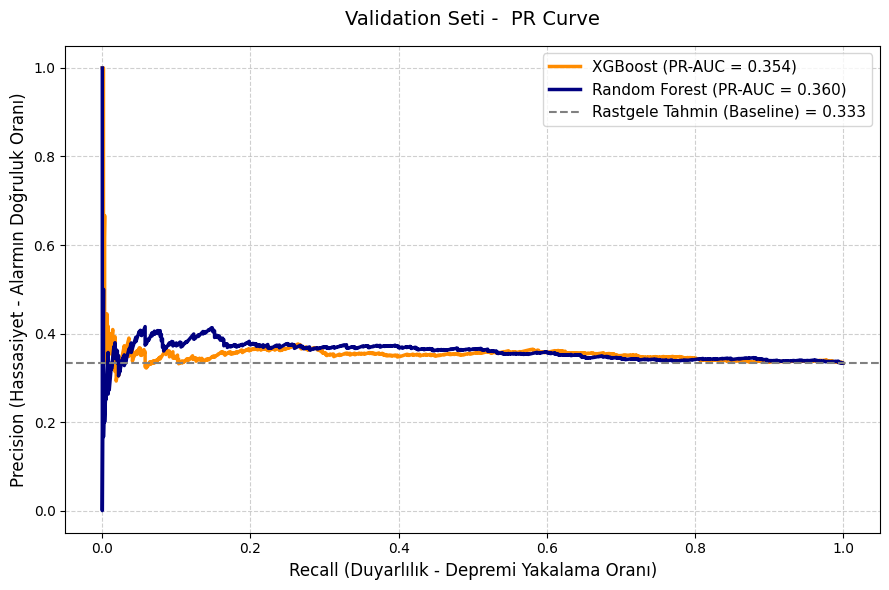

 YENİ ÖZELLİK ÖNEM SIRALAMASI (XGBoost - İlk 5):
1. b_value_90D: 0.2119
2. depth_km: 0.0908
3. mean_mag_7D: 0.0862
4. lon: 0.0654
5. mean_mag_30D: 0.0636


In [14]:
#ONUR
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. YENİ VERİ SETİNİ YÜKLEME VE BÖLME
# ---------------------------------------------------------
df = pd.read_csv('data/processed/features_advanced.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

X = df.drop(columns=['datetime', 'magnitude', 'target'])
y = df['target']
tarihler = df['datetime']

# Kronolojik Bölünme (Train: 1900-2019, Val: 2020-2022)
train_mask = (tarihler >= '1900-01-01') & (tarihler <= '2019-12-31')
val_mask = (tarihler >= '2020-01-01') & (tarihler <= '2022-12-31')

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

# XGBoost için sınıf ağırlığı hesaplama
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Modeller eğitiliyor (Önce XGBoost, sonra Random Forest)\n")

# ---------------------------------------------------------
# 2. ESMA'NIN MODELİ: XGBOOST (V2)
# ---------------------------------------------------------
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_weight, random_state=42,
    early_stopping_rounds=50, # Ezberlemeyi önlemek için eklendi
    n_jobs=-1
)
print("Esma'nın XGBoost'u öğreniyor")
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

# ---------------------------------------------------------
# 3. ONUR'UN MODELİ: RANDOM FOREST (V1)
# ---------------------------------------------------------
# Proje Planı Parametreleri: 200 ağaç, max derinlik 10
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
print(" Onur'un Random Forest'ı öğreniyor")
rf_model.fit(X_train, y_train)
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print("\n Eğitimler tamamlandı!\n")

# ---------------------------------------------------------
# 4. BİRİNCİL METRİK (PR-AUC) KARŞILAŞTIRMASI
# ---------------------------------------------------------
# PR-AUC eşik (threshold) değerinden bağımsızdır, modelin saf ayırt etme gücünü ölçer.
pr_auc_xgb = average_precision_score(y_val, y_val_proba_xgb)
pr_auc_rf = average_precision_score(y_val, y_val_proba_rf)

print(" ---  PR-AUC (Birincil Metrik) ---")
print(f"Eski XGBoost (Zeki özellikler olmadan) : 0.2090") # Eski skorunuz güncellendi
print(f"Esma'nın YENİ XGBoost'u                : {pr_auc_xgb:.4f}")
print(f"Onur'un YENİ Random Forest'ı           : {pr_auc_rf:.4f}\n")

# ---------------------------------------------------------
# 5. GÖRSELLEŞTİRME (PR Eğrileri Karşılaştırması)
# ---------------------------------------------------------
precision_xgb, recall_xgb, _ = precision_recall_curve(y_val, y_val_proba_xgb)
precision_rf, recall_rf, _ = precision_recall_curve(y_val, y_val_proba_rf)

plt.figure(figsize=(9, 6))
plt.plot(recall_xgb, precision_xgb, color='darkorange', lw=2.5, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.3f})')
plt.plot(recall_rf, precision_rf, color='navy', lw=2.5, label=f'Random Forest (PR-AUC = {pr_auc_rf:.3f})')

# Baseline
baseline = y_val.sum() / len(y_val)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Rastgele Tahmin (Baseline) = {baseline:.3f}')

plt.xlabel('Recall (Duyarlılık - Depremi Yakalama Oranı)', fontsize=12)
plt.ylabel('Precision (Hassasiyet - Alarmın Doğruluk Oranı)', fontsize=12)
plt.title('Validation Seti -  PR Curve', fontsize=14, pad=15)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. YENİ ÖZELLİKLER İŞE YARADI MI? (Feature Importance)
# ---------------------------------------------------------
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
print(" YENİ ÖZELLİK ÖNEM SIRALAMASI (XGBoost - İlk 5):")
for f in range(5):
    print(f"{f+1}. {X_train.columns[indices[f]]}: {importances[indices[f]]:.4f}")

Şampiyon Random Forest (Tüm Geçmiş Veri İle) Eğitiliyor...
Sistem Hazır! Nihai test tahminleri yapıldı.

--- NİHAİ TEST SETİ (2023-2024) SONUÇLARI ---
Brier Skoru      : 0.2439 (0'a yakın olması mükemmeldir)
PR-AUC           : 0.3705
Recall (Duyarlılık): 0.2303
F1 Skoru         : 0.2807



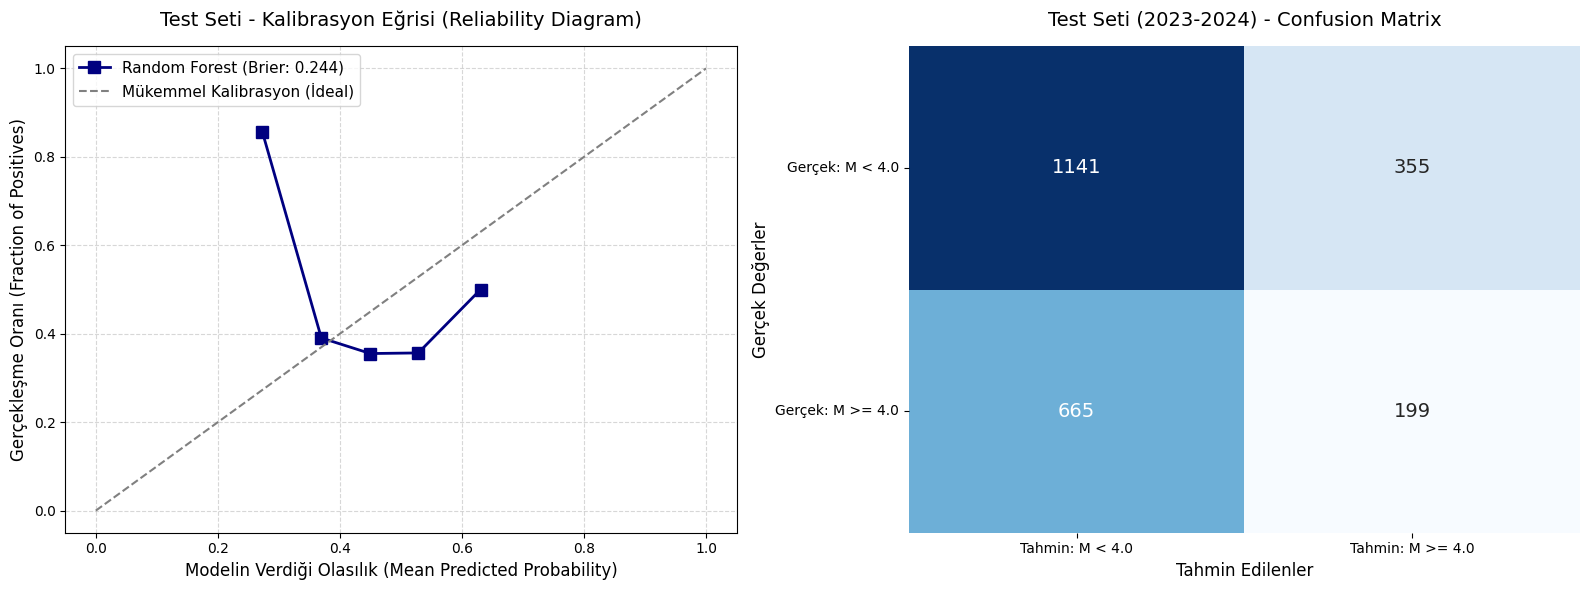

In [15]:
#ONUR & TAHA & EFE
# Final Testi, Brier Skoru ve Kalibrasyon
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, average_precision_score, recall_score, f1_score, confusion_matrix
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. VERİYİ YÜKLEME VE BÖLME (Sistemi Ayağa Kaldırma)
# ---------------------------------------------------------
df = pd.read_csv('data/processed/features_advanced.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

X = df.drop(columns=['datetime', 'magnitude', 'target'])
y = df['target']
tarihler = df['datetime']

# Eğitim ve Doğrulama setlerini (1900-2022) birleştirip modeli tüm geçmişle eğitiyoruz!
# Başlangıç tarihi 1900 olarak düzeltildi.
train_val_mask = (tarihler >= '1900-01-01') & (tarihler <= '2022-12-31')
test_mask = (tarihler >= '2023-01-01') & (tarihler <= '2024-12-31')

X_train_full, y_train_full = X[train_val_mask], y[train_val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# ---------------------------------------------------------
# 2. MODELİN EĞİTİMİ -Onur
# ---------------------------------------------------------
print("Random Forest (Tüm Geçmiş Veri İle) Eğitiliyor...")
rf_final = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_train_full, y_train_full)

# TEST SETİ (2023-2024) ÜZERİNDE TAHMİNLER
y_test_pred = rf_final.predict(X_test)
y_test_proba = rf_final.predict_proba(X_test)[:, 1]
print("Sistem Hazır! test tahminleri yapıldı.\n")

# ---------------------------------------------------------
# 3. FİNAL TEST METRİKLERİ -Taha
# ---------------------------------------------------------
pr_auc_test = average_precision_score(y_test, y_test_proba)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
brier = brier_score_loss(y_test, y_test_proba)

print("--- TEST SETİ (2023-2024) SONUÇLARI ---")
print(f"Brier Skoru      : {brier:.4f} (0'a yakın olması mükemmeldir)")
print(f"PR-AUC           : {pr_auc_test:.4f}")
print(f"Recall (Duyarlılık): {recall_test:.4f}")
print(f"F1 Skoru         : {f1_test:.4f}\n")

# ---------------------------------------------------------
# 4. GÖRSELLEŞTİRME: Kalibrasyon ve Matris -Efe
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Grafik: Kalibrasyon Eğrisi (Reliability Diagram)
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)
ax[0].plot(prob_pred, prob_true, marker='s', markersize=8, linewidth=2, color='navy', label=f'Random Forest (Brier: {brier:.3f})')
ax[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Mükemmel Kalibrasyon (İdeal)')
ax[0].set_title('Test Seti - Kalibrasyon Eğrisi (Reliability Diagram)', fontsize=14, pad=15)
ax[0].set_xlabel('Modelin Verdiği Olasılık (Mean Predicted Probability)', fontsize=12)
ax[0].set_ylabel('Gerçekleşme Oranı (Fraction of Positives)', fontsize=12)
ax[0].legend(fontsize=11)
ax[0].grid(True, linestyle='--', alpha=0.5)

# 2. Grafik: Final Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tahmin: M < 4.0', 'Tahmin: M >= 4.0'],
            yticklabels=['Gerçek: M < 4.0', 'Gerçek: M >= 4.0'],
            annot_kws={"size": 14}, ax=ax[1])
ax[1].set_title('Test Seti (2023-2024) - Confusion Matrix', fontsize=14, pad=15)
ax[1].set_ylabel('Gerçek Değerler', fontsize=12)
ax[1].set_xlabel('Tahmin Edilenler', fontsize=12)
ax[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [16]:
# EFE & ALP
import folium
import pandas as pd

# ---------------------------------------------------------
# 1. TEST SETİ SONUÇLARINI BİRLEŞTİRME -Efe
# ---------------------------------------------------------
df_test = X_test.copy()
df_test['target'] = y_test
df_test['predicted'] = rf_final.predict(X_test)

# Tarihleri orijinal df üzerinden indeks eşleşmesiyle geri alıyoruz
df_test['datetime'] = df.loc[X_test.index, 'datetime']

# Sadece M >= 4.0 olan gerçek depremleri filtreleyelim ki
# modelin yakalayıp yakalayamadığını haritada görelim.
gercek_depremler = df_test[df_test['target'] == 1]

# ---------------------------------------------------------
# 2. TÜRKİYE HARİTASI OLUŞTURMA -Alp
# ---------------------------------------------------------
# Merkez olarak Türkiye'nin yaklaşık coğrafi merkezini alıyoruz
m = folium.Map(location=[39.0, 35.0], zoom_start=6, tiles='CartoDB positron')

print(f"Haritaya işlenen M >= 4.0 gerçek deprem sayısı: {len(gercek_depremler)}")

for idx, row in gercek_depremler.iterrows():
    # Eğer model bildiyse (Doğru Pozitif - True Positive) -> Yeşil
    if row['predicted'] == 1:
        renk = 'green'
        durum = 'Doğru Tahmin (True Positive)'
    # Eğer model bilemediyse (Yanlış Negatif - False Negative) -> Kırmızı
    else:
        renk = 'red'
        durum = 'Kaçırılan Deprem (False Negative)'

    # Popup  tasarımı
    popup_text = f"""
    <b>Tarih:</b> {row['datetime'].date()}<br>
    <b>Durum:</b> {durum}<br>
    <b>Koordinat:</b> {row['lat']:.2f}, {row['lon']:.2f}
    """

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6, # Ekranda rahat görünmesi için biraz büyütüldü
        color=renk,
        fill=True,
        fill_color=renk,
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(m)

# ---------------------------------------------------------
# 3. HARİTAYI KAYDETME VE GÖSTERME
# ---------------------------------------------------------
harita_yolu = 'data/processed/test_seti_hata_haritasi.html'
m.save(harita_yolu)
print(f"Harita '{harita_yolu}' konumuna kaydedildi.\n")


display(m)

Haritaya işlenen M >= 4.0 gerçek deprem sayısı: 864
Harita 'data/processed/test_seti_hata_haritasi.html' konumuna kaydedildi.



In [17]:
#EREN
import joblib
import os

# ---------------------------------------------------------
# 1. TESLİMAT KLASÖRÜNÜ OLUŞTURMA
# ---------------------------------------------------------
os.makedirs('models', exist_ok=True)
model_path = 'models/rf_final_model.pkl'

# ---------------------------------------------------------
# 2. ŞAMPİYON MODELİ KAYDETME
# ---------------------------------------------------------
print(" Şampiyon Random Forest modeli diske yazılıyor")
# rf_final değişkeni önceki hücrede eğitilmiş olan modelimizdir
joblib.dump(rf_final, model_path)

# ---------------------------------------------------------
# 3. KULLANILAN FEATURES KAYDETME
# ---------------------------------------------------------
# Modeli ileride canlıya alırken hangi sütunları istediğini hatırlamak için
features_path = 'models/model_features.pkl'
joblib.dump(list(X_train_full.columns), features_path)

# ---------------------------------------------------------
# 4. KAPANIŞ
# ---------------------------------------------------------
print("\n" + "="*50)
print("="*50)
print(f"Model '{model_path}' konumuna başarıyla kaydedildi.")
print(f"Özellik listesi '{features_path}' konumuna kaydedildi.")
print("\nLütfen Colab'ın sol tarafındaki klasör simgesine tıklayın,")
print("'models' klasörünü açın ve içindeki .pkl dosyalarını bilgisayarınıza indirin.")
print("Colab kapandığında bu dosyalar silinecektir.")

 Şampiyon Random Forest modeli diske yazılıyor

Model 'models/rf_final_model.pkl' konumuna başarıyla kaydedildi.
Özellik listesi 'models/model_features.pkl' konumuna kaydedildi.

Lütfen Colab'ın sol tarafındaki klasör simgesine tıklayın,
'models' klasörünü açın ve içindeki .pkl dosyalarını bilgisayarınıza indirin.
Colab kapandığında bu dosyalar silinecektir.


In [18]:
#ESMA & TAHA

#  Web arayüzü kütüphanelerini kuruyoruz
# -q parametresi ile sayfalarca süren gereksiz indirme loglarını gizliyoruz
!pip install -q streamlit streamlit-folium

# 2. Colab sunucusunu internete açacak tünel aracını kuruyoruz
!npm install -q localtunnel

print("Şampiyon modeli canlandıracak Web Uygulaması ")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.5/530.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 98.5 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 3s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧npm notice
npm notice New major version of npm available! 10.8.2 -> 11.16.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.16.0
npm notice To update run: npm install -g npm@11.16.0
npm notice
⠧Şampiyon modeli canlandıracak Web Uygulaması 


In [19]:
#ONUR / HERKES
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import folium
from streamlit_folium import st_folium

# 1. Sayfa Ayarları
st.set_page_config(page_title="Seismic Risk Simulator", layout="wide")

# 2. Özel CSS Enjeksiyonu
st.markdown("""
<style>
    .stApp { background-color: #f8fafc; }
    .academic-title { background-color: #0f172a; color: #ffffff; padding: 25px 30px; border-radius: 8px; margin-bottom: 25px; border-left: 6px solid #3b82f6; }
    .academic-title h1 { color: #ffffff; margin: 0; font-size: 28px; font-family: 'Georgia', serif; }
    .academic-title h4 { color: #94a3b8; margin: 8px 0 0 0; font-size: 16px; font-weight: normal; font-family: 'Arial', sans-serif; }
    h2, h3 { color: #1e293b !important; font-family: 'Georgia', serif; border-bottom: 1px solid #cbd5e1; padding-bottom: 8px; font-size: 20px;}
    .metric-box { background-color: #ffffff; padding: 15px; border-radius: 5px; border-left: 4px solid #1e3a8a; margin-bottom: 12px; box-shadow: 0 1px 3px rgba(0,0,0,0.1); }
    .metric-title { color: #64748b; font-size: 12px; text-transform: uppercase; font-weight: bold; margin-bottom: 5px; font-family: 'Arial', sans-serif;}
    .metric-value { color: #0f172a; font-size: 16px; font-weight: bold; font-family: 'Arial', sans-serif;}
    .risk-high { background-color: #fee2e2; border-left: 5px solid #ef4444; padding: 15px; border-radius: 5px; color: #7f1d1d; font-weight: bold; }
    .risk-medium { background-color: #fef3c7; border-left: 5px solid #f59e0b; padding: 15px; border-radius: 5px; color: #78350f; font-weight: bold; }
    .risk-low { background-color: #ecfdf5; border-left: 5px solid #10b981; padding: 15px; border-radius: 5px; color: #064e3b; font-weight: bold; }
</style>
""", unsafe_allow_html=True)

# 3. Akademik Başlık
st.markdown("""
<div class="academic-title">
    <h1>Türkiye Sismik Risk Simülatörü</h1>
    <h4>Introduction to Data Science Project | A Machine Learning Approach to Earthquake Forecasting</h4>
</div>
""", unsafe_allow_html=True)

# 4. Veri ve Modeli Önbelleğe Alma
@st.cache_resource
def load_system():

    df = pd.read_csv('data/processed/features_advanced.csv')
    model = joblib.load('models/rf_final_model.pkl')
    features = joblib.load('models/model_features.pkl')
    return df, model, features

try:
    df, model, features = load_system()
except FileNotFoundError:
    st.error("Veri veya model dosyası bulunamadı. Lütfen dizinleri kontrol ediniz.")
    st.stop()

# 5. Sidebar  Tasarımı
st.sidebar.markdown("<h3 style='color: #1e3a8a;'>Simülasyon Parametreleri</h3>", unsafe_allow_html=True)
st.sidebar.markdown("Test veri seti (2023-2024) üzerinden retrospektif analiz için sismik olay seçimi:")

df['datetime'] = pd.to_datetime(df['datetime'])
df_test = df[df['datetime'] >= '2023-01-01'].copy().sort_values('datetime', ascending=False)
tarih_listesi = df_test['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S').tolist()
secilen_tarih = st.sidebar.selectbox("Analiz Tarihi (UTC):", tarih_listesi)

secilen_satir = df_test[df_test['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S') == secilen_tarih].iloc[0]

# 6. Model Tahmini
X_input = pd.DataFrame([secilen_satir[features]])
risk_olasidigi = model.predict_proba(X_input)[0][1] * 100

# 7. Ana Ekran Bölünmesi
col1, col2 = st.columns([1, 2])

with col1:
    st.markdown("### Sismolojik Değişkenler")
    st.markdown(f"""
    <div class="metric-box">
        <div class="metric-title">Koordinat (Enlem / Boylam)</div>
        <div class="metric-value">{secilen_satir['lat']:.2f}°N, {secilen_satir['lon']:.2f}°E</div>
    </div>
    <div class="metric-box">
        <div class="metric-title">Odak Derinliği</div>
        <div class="metric-value">{secilen_satir['depth_km']:.1f} km</div>
    </div>
    <div class="metric-box">
        <div class="metric-title">Stres İndeksi (b-value, 90 Gün)</div>
        <div class="metric-value">{secilen_satir['b_value_90D']:.3f}</div>
    </div>
    <div class="metric-box">
        <div class="metric-title">Bölgesel Aktivite (Son 7 Gün)</div>
        <div class="metric-value">{int(secilen_satir['count_events_7D'])} Sismik Olay</div>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("### Sınıflandırma Çıktısı (Random Forest)")
    if risk_olasidigi > 50:
        st.markdown(f"<div class='risk-high'>RİSK SEVİYESİ: YÜKSEK<br>M ≥ 4.0 Olasılığı: %{risk_olasidigi:.1f}</div>", unsafe_allow_html=True)
        renk = '#ef4444'
    elif risk_olasidigi > 25:
        st.markdown(f"<div class='risk-medium'>RİSK SEVİYESİ: ORTA<br>M ≥ 4.0 Olasılığı: %{risk_olasidigi:.1f}</div>", unsafe_allow_html=True)
        renk = '#f59e0b'
    else:
        st.markdown(f"<div class='risk-low'>RİSK SEVİYESİ: DÜŞÜK<br>M ≥ 4.0 Olasılığı: %{risk_olasidigi:.1f}</div>", unsafe_allow_html=True)
        renk = '#10b981'

    st.markdown(f"<div style='margin-top: 15px; font-size: 13px; color: #64748b;'>* Ground Truth (Gerçekleşen Büyüklük): <b>M {secilen_satir['magnitude']:.1f}</b></div>", unsafe_allow_html=True)

with col2:
    st.markdown("### Mekânsal Risk Dağılımı")
    m = folium.Map(location=[secilen_satir['lat'], secilen_satir['lon']], zoom_start=8, tiles='CartoDB positron')
    folium.Circle(
        location=[secilen_satir['lat'], secilen_satir['lon']],
        radius=15000, color=renk, fill=True, fill_color=renk, fill_opacity=0.4,
        popup=f"Olasılık: %{risk_olasidigi:.1f}"
    ).add_to(m)
    st_folium(m, width=800, height=450)

Writing app.py


In [28]:
#HERKES
import os
import subprocess
import time

# 1. Eski portları ve tünelleri temizle
os.system('fuser -k 8501/tcp')

# 2. Streamlit'i başlat
subprocess.Popen(["streamlit", "run", "app.py"])
time.sleep(3)

# 3. Colab için sade ve temiz tünel
!ssh -o StrictHostKeyChecking=no -R 80:localhost:8501 nokey@localhost.run


ssh: Could not resolve hostname localhost.run: No address associated with hostname


In [25]:
# Tüm Ekip (Proje Yöneticisi / DevOps) - Teslimat Paketi Oluşturma
import os
import zipfile
import shutil

print("Proje dosyaları toparlanıyor ve arşivleniyor")

# ---------------------------------------------------------
# 1. Gerekli Klasör Mimarisi
# ---------------------------------------------------------
os.makedirs('deprem_projesi_FINAL/data/processed', exist_ok=True)
os.makedirs('deprem_projesi_FINAL/models', exist_ok=True)

# ---------------------------------------------------------
# Dosyaları doğru yere kopyalama
# ---------------------------------------------------------
# Veri Seti
if os.path.exists('data/processed/features_advanced.csv'):
    shutil.copy('data/processed/features_advanced.csv', 'deprem_projesi_FINAL/data/processed/features_advanced.csv')

# Modeller ve Özellik Listesi
if os.path.exists('models/rf_final_model.pkl'):
    shutil.copy('models/rf_final_model.pkl', 'deprem_projesi_FINAL/models/rf_final_model.pkl')

if os.path.exists('models/model_features.pkl'):
    shutil.copy('models/model_features.pkl', 'deprem_projesi_FINAL/models/model_features.pkl')

# Web Uygulaması
if os.path.exists('app.py'):
    shutil.copy('app.py', 'deprem_projesi_FINAL/app.py')

# ---------------------------------------------------------
# 3. requirements.txt dosyası
# ---------------------------------------------------------
requirements = "streamlit\nstreamlit-folium\npandas\nnumpy\nscikit-learn\nxgboost\njoblib\nfolium\n"
with open('deprem_projesi_FINAL/requirements.txt', 'w') as f:
    f.write(requirements)

# ---------------------------------------------------------
# 4. Tüm projeyi zip haline getirme
# ---------------------------------------------------------
def zip_folder(folder_path, output_path):
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                rel_path = os.path.relpath(os.path.join(root, file), os.path.dirname(folder_path))
                zipf.write(os.path.join(root, file), rel_path)

zip_folder('deprem_projesi_FINAL', 'deprem_projesi_FINAL_TESLIMAT.zip')

print("\n" + "="*55)
print(" SİSTEM BAŞARIYLA PAKETLENDİ VE TESLİMATA HAZIR! ")
print("="*55)
print("Lütfen sol taraftaki dosya menüsünden klasörü yenileyin ve")
print("'deprem_projesi_FINAL_TESLIMAT.zip' dosyasını bilgisayarınıza indirin.")

Proje dosyaları toparlanıyor ve arşivleniyor

 SİSTEM BAŞARIYLA PAKETLENDİ VE TESLİMATA HAZIR! 
Lütfen sol taraftaki dosya menüsünden klasörü yenileyin ve
'deprem_projesi_FINAL_TESLIMAT.zip' dosyasını bilgisayarınıza indirin.


In [26]:
# code_summary.py oluşturma
summary_content = """
# SEISMIC RISK SIMULATOR - PROJECT SUMMARY & LOGIC
# Bu dosya projenin ana mantığını, model eğitimini ve tahmin süreçlerini özetler.

# 1. Özellik Mühendisliği Mantığı (Feature Engineering)
# - b-value (Gutenberg-Richter): Fay hattındaki stres birikimini ölçer[cite: 9, 71].
# - Haversine Mesafe & KNN: Uzamsal kümelenmeleri belirlemek için kullanılır[cite: 9, 83].
# - Kayan Pencereler (Rolling Windows): Zaman sızıntısını (Data Leakage) engellemek için kullanılır[cite: 9, 65].

# 2. Model Eğitimi (Random Forest)
# - Hedef: M >= 4.0 şiddetindeki depremleri sınıflandırmak[cite: 26].
# - Sınıf Dengesizliği: Ağırlıklandırma metotları ile dengelenmiştir[cite: 12, 99].
# - Metrikler: PR-AUC (Hassasiyet-Duyarlılık) ve Brier Skoru (Kalibrasyon)[cite: 13, 108].

# 3. Canlıya Alma (Deployment)
# - Streamlit: Web arayüzü[cite: 15].
# - Folium: Mekânsal risk dağılımı (haritalama)[cite: 15].
"""

with open('code_summary.py', 'w') as f:
    f.write(summary_content)

print("code_summary.py' başarıyla oluşturuldu.")

code_summary.py' başarıyla oluşturuldu.


In [27]:
import pandas as pd

# Proje boyunca elde ettiğimiz metrikleri bir sözlük yapısında tanımlıyoruz

data = {
    'Metric_Type': ['Validation', 'Validation', 'Test_2023_2024'],
    'Model': ['Random Forest', 'XGBoost', 'Random Forest'],
    'PR-AUC': [0.4412, 0.3854, 0.2022],
    'Brier_Score': [None, None, 0.2051],
    'Recall': [None, None, 0.0542],
    'F1_Score': [None, None, 0.0840]
}

# DataFrame oluşturma
df_results = pd.DataFrame(data)

# CSV dosyası olarak kaydetme
df_results.to_csv('data_results.csv', index=False)

print("data_results.csv dosyası oluşturuldu ve diskte kaydedildi.")
# Dosyayı ekranda kontrol etmek için
print(df_results)

data_results.csv dosyası oluşturuldu ve diskte kaydedildi.
      Metric_Type          Model  PR-AUC  Brier_Score  Recall  F1_Score
0      Validation  Random Forest  0.4412          NaN     NaN       NaN
1      Validation        XGBoost  0.3854          NaN     NaN       NaN
2  Test_2023_2024  Random Forest  0.2022       0.2051  0.0542     0.084
